# Machine Learning + PLC Data

Implementar: 
- Random Forest / XGBoost
Si quieres un modelo menos costoso en cómputo, podrías usar Random Forest o XGBoost para predecir los setpoints de forma más rápida y explicable.
- Reinforcement Learning: 
    -  Deep Q-Learning (DQN)
Define estados como la temperatura actual, la posición de la válvula, etc.
Define acciones como aumentar/disminuir la válvula o modificar el setpoint.
Define recompensas en base a qué tan rápido se estabiliza el sistema.
    - Proximal Policy Optimization (PPO)
Más avanzado que DQN, aprende políticas óptimas para ajustar el sistema de manera más eficiente.

## 1. Preprocesamiento de Datos

- Convertir datos de un archivo CSV a un DataFrame de Pandas
- Manejo valores faltantes/erroneos
- Nomrmalización o escalado

Realizo un dataframe inventando con 171 datos para cada TAG

In [68]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Definir el rango de fechas
start_date = datetime(2025, 2, 11, 17, 54, 59)
end_date = datetime(2025, 2, 18, 20, 30, 00)
date_range = pd.date_range(start=start_date, end=end_date, freq='H')

# Crear un DataFrame vacío
data = {
    '_start': [],
    '_stop': [],
    '_time': [],
    '_value': [],
    '_field': [],
    '_measurement': []
}

measurements = ['FT1501', 'Pc_OIT_24Real[291]', 'LT1503', 'TT1502', 'MSC1504', 'TT1501', 'MSC1001', 'CV1801', 'MSC1505', 'Pc_OIT_24Real[290]', 'TT1501Pid', 'LT1301', 'MSC1503', 'MSC1301', 'DeltaTPid']

# Generar datos sintéticos
for measurement in measurements:
    for date in date_range:
        data['_start'].append(start_date)
        data['_stop'].append(end_date)
        data['_time'].append(date)
        if measurement == 'TT1501Pid':
            data['_value'].append(194)  # Valor constante para TT1501Pid
        elif measurement == 'DeltaTPid':
            data['_value'].append(46)  # Valor constante para DeltaTPid
        else:
            data['_value'].append(np.random.randn())  # Valores aleatorios para otros measurements
        data['_field'].append('Value')
        data['_measurement'].append(measurement)

# Crear el DataFrame
df = pd.DataFrame(data)

# Mostrar el DataFrame
print(df.shape)
print(df.head())

# Guardar el DataFrame en un archivo CSV
df.to_csv('data_sintetica.csv', index=False)

(2565, 6)
               _start               _stop               _time    _value  \
0 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 17:54:59 -0.436868   
1 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 18:54:59 -0.104590   
2 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 19:54:59  0.293481   
3 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 20:54:59  0.123470   
4 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 21:54:59  1.122574   

  _field _measurement  
0  Value       FT1501  
1  Value       FT1501  
2  Value       FT1501  
3  Value       FT1501  
4  Value       FT1501  


Pongo en columnas cada TAG con sus values como valores.

In [69]:
# Pivotar el DataFrame para tener columnas de cada medición y el campo
df_pivoted = df.pivot_table(index=['_start', '_stop', '_time'], columns='_measurement', values='_value')

# Restablecer el índice para que '_start', '_stop', '_time' y '_field' sean columnas
df_pivoted.reset_index(inplace=True)

# Mostrar el DataFrame resultante
print(df_pivoted.head())

_measurement              _start               _stop               _time  \
0            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 17:54:59   
1            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 18:54:59   
2            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 19:54:59   
3            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 20:54:59   
4            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 21:54:59   

_measurement    CV1801  DeltaTPid    FT1501    LT1301    LT1503   MSC1001  \
0            -1.229228       46.0 -0.436868  1.610814 -1.362470 -1.487085   
1            -0.788067       46.0 -0.104590  0.946707  0.862393 -0.796913   
2            -1.201488       46.0  0.293481 -0.875991  1.155173 -1.346487   
3            -1.185762       46.0  0.123470  0.215240 -0.298576  0.197826   
4            -0.362311       46.0  1.122574 -1.419419  0.102158 -0.292560   

_measurement   MSC1301   MSC1503   MSC1504   MSC1505  Pc_OIT_24Real[290]  \
0   

### Esto para cuando usamos la bdd de InfluxDB

In [ ]:
import pandas as pd

data = pd.read_csv('data.csv', skiprows=3)

df = pd.DataFrame(data)
print(df)

In [ ]:
# Drop the columns 'Unnamed: 0' and 'result'
df = df.drop(columns=['result'])
df = df.drop(columns=['Unnamed: 0'])

# Display the DataFrame
print(df)

## 2. SP Intercambiador

### 2.1. Preprocesar Datos para LSTM

In [70]:
from sklearn.preprocessing import MinMaxScaler

# Seleccionar las series temporales de interés
series_temp_intercambiador = df_pivoted['TT1501Pid']
series_valvula_gas = df_pivoted['CV1801']
series_temp_camara = df_pivoted['Pc_OIT_24Real[291]']

# Normalizar los datos DE 0 A 1
scaler = MinMaxScaler(feature_range=(0, 1))
series_temp_intercambiador_scaled = scaler.fit_transform(series_temp_intercambiador.values.reshape(-1, 1))
series_valvula_gas_scaled = scaler.fit_transform(series_valvula_gas.values.reshape(-1, 1))
series_temp_camara_scaled = scaler.fit_transform(series_temp_camara.values.reshape(-1, 1))

# Crear secuencias de datos para el modelo LSTM
def create_sequences(data, seq_length): #toma una serie de datos y una longitud de secuencia
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences) #devuelve una lista de secuencias de longitud seq_length. Cada secuencia es una subsecuencia de la serie de datos original

# generar secuencias para cada serie temporal
seq_length = 10
sequences_temp_intercambiador = create_sequences(series_temp_intercambiador_scaled, seq_length)
sequences_valvula_gas = create_sequences(series_valvula_gas_scaled, seq_length)
sequences_temp_camara = create_sequences(series_temp_camara_scaled, seq_length)

# Concatenar todas las secuencias
# cada secuecia tiene 3 columnas(SP temp intercambiador, posicion valvula de gas y temp camara intermbiador), una para cada serie temporal
sequences = np.concatenate([sequences_temp_intercambiador, sequences_valvula_gas, sequences_temp_camara], axis=2)

# Dividir los datos en entrenamiento y prueba
train_size = int(len(sequences) * 0.8)
train_sequences, test_sequences = sequences[:train_size], sequences[train_size:]

# Separar características y etiquetas
X_train = train_sequences[:, :-1] #Caracteristicas del conjunto train, todas las secuencias menos la ultima
y_train = train_sequences[:, -1, 0]  # Usamos la temperatura del intercambiador como etiqueta, utlimo valor de temp del intercambiador en c/secuencia
X_test = test_sequences[:, :-1]
y_test = test_sequences[:, -1, 0]

Esto normalizo las series temporales, creo secuencias de datos y se dividio en conjuntos de entrenamiento y prueba.

### 2.2. Construir y entrenar modelo

LSTM:
-  Long Short-Term Memory, tipo de red neuronal recurrente para modelar secuencias y dependencias a largo plazo. 
- es una red neuronal recurrente que es capaz de aprender dependencias temporales en los datos.
- para predecir la temperatura de salida del intercambiador de calor.

Uso Dense para la capa de salida, que es una capa de red neuronal estándar que produce una salida de un solo valor.

Uso Dropout para regularizar el modelo y evitar el sobreajuste durante el entrenamiento. 

- **LSTM(50, return_sequences=True, input_shape=(seq_length - 1, 3)):** Añade una capa LSTM con 50 unidades. **return_sequences=True** indica que la capa LSTM debe devolver la secuencia completa de salida para cada entrada. **input_shape=(seq_length - 1, 3)** especifica la forma de la entrada, donde seq_length - 1 es la longitud de la secuencia y 3 es el número de características (temperatura del intercambiador, posición de la válvula de gas y temperatura de la cámara del intercambiador).

LSTM tiene 50 celdas de memoria y, por lo tanto, puede aprender 50 patrones o características diferentes de los datos secuenciales. Cuantas más unidades tenga una capa LSTM, mayor será su capacidad para aprender patrones complejos, aunque también aumentará el riesgo de sobreajuste y el tiempo de entrenamiento.

- **Dropout(0.2):** Añade una capa de dropout con una tasa de 0.2. El 20% de las unidades de la capa anterior se desactivarán aleatoriamente durante el entrenamiento para prevenir el sobreajuste.
- **LSTM(50, return_sequences=False):** Añade otra capa LSTM con 50 unidades. return_sequences=False indica que esta capa LSTM debe devolver solo la última salida en la secuencia de salida.
- **Dense(1):** Añade una capa densa con una unidad de salida. Esta capa se utiliza para producir la predicción final del modelo.

In [71]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length - 1, 3)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

#compilar el modelo
# adam para actualizar los pesos del modelo durante training
# loss= mean squared error, uso esta como fucnion de perdida, mide la dif promedio al cuadrado entre las predicciones del modelo y los valores reales. 
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
# 20 iteraciones sobre conjunto training
# batch_size=32, tamaño de lote, numero de muestras que se usan para actualizar los pesos del modelo
# validation_data=(X_test, y_test), conjunto de validacion
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
4/4 [==============================] - 4s 286ms/step - loss: 8.9620e-04 - val_loss: 4.0060e-04
Epoch 2/20
4/4 [==============================] - 0s 20ms/step - loss: 5.9683e-04 - val_loss: 1.9496e-04
Epoch 3/20
4/4 [==============================] - 0s 22ms/step - loss: 5.4449e-04 - val_loss: 2.8980e-06
Epoch 4/20
4/4 [==============================] - 0s 19ms/step - loss: 2.9654e-04 - val_loss: 7.7114e-05
Epoch 5/20
4/4 [==============================] - 0s 19ms/step - loss: 2.1226e-04 - val_loss: 4.1355e-05
Epoch 6/20
4/4 [==============================] - 0s 21ms/step - loss: 2.4797e-04 - val_loss: 2.3029e-05
Epoch 7/20
4/4 [==============================] - 0s 20ms/step - loss: 1.1680e-04 - val_loss: 4.1135e-05
Epoch 8/20
4/4 [==============================] - 0s 19ms/step - loss: 1.3911e-04 - val_loss: 1.0313e-06
Epoch 9/20
4/4 [==============================] - 0s 18ms/step - loss: 1.1821e-04 - val_loss: 4.1763e-05
Epoch 10/20
4/4 [==============================] - 0s 

- loss: funncion de perdida en conjunto de train. 
- val_loss: funcion de perdiad en conjunto de validacion.

Pérdida Baja: Se busca que tanto la pérdida de entrenamiento (loss) como la pérdida de validación (val_loss) sean lo más bajas posible. Esto indica que el modelo está haciendo buenas predicciones tanto en los datos de entrenamiento como en los de validación.


Consistencia: Se busca que la pérdida de validación no aumente significativamente en comparación con la pérdida de entrenamiento. Un aumento significativo en la pérdida de validación puede ser una señal de sobreajuste, donde el modelo está memorizando los datos de entrenamiento en lugar de aprender patrones generales.

### 2.3. Hacer Predicciones y Ajustar Válvula de Gas

Se usa el moedlo LSTM entrenado para hacer predcicciones sobre X_test. Esto luego me da un array de predicciones para cada secuencia en el conjunto de prueba. 

- **inverse_transform:** Se invierte la normalizacion de las predicciones y los valores reales para compararlos. Necesario porque los datos fueron normalizados antes de ser usados en el modelo. 
- **reshape(-1, 1):** Cambia la forma de los datos a un vector columna. Reorganizo y_test en una matriz de 2 dimensiones con 1 columna, para aplicar transofrmacion inversa.

Se ajusta la valuvla de gas en el PLC a los valores predicios por el moedelo LSTM.



In [72]:
from pylogix import PLC

# Hacer predicciones
predictions = model.predict(X_test)

# Invertir la normalización
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Función para ajustar la válvula de gas en el PLC
def adjust_valve(plc_ip, tag_name, new_value): # funcion para ajustar la valvula de gas en el PLC
    with PLC() as comm:
        comm.IPAddress = plc_ip # IP PLC
        comm.Write(tag_name, new_value) #escribe nuevo valor en el tag del plc
        print(f"Válvula de gas ajustada a: {new_value}") #imprime el valor ajustado

# Ajustar la válvula de gas en función de las predicciones
plc_ip = "aaa.bbb.ccc.ddd"
tag_name = "CV1801.VALUE"
for i in range(len(predictions)): #itero sobre predicciones y llamo a funcion adjust_valve
    #para ajustar la valula de gas en el PLC con el valor predicho correspondiene
    adjust_valve(plc_ip, tag_name, predictions[i][0])

2/2 [==============================] - 1s 6ms/step
Válvula de gas ajustada a: -2.7728703022003174
Válvula de gas ajustada a: -2.7742345333099365
Válvula de gas ajustada a: -2.7779314517974854
Válvula de gas ajustada a: -2.7785065174102783
Válvula de gas ajustada a: -2.7789645195007324
Válvula de gas ajustada a: -2.778965711593628
Válvula de gas ajustada a: -2.7771737575531006
Válvula de gas ajustada a: -2.7779181003570557
Válvula de gas ajustada a: -2.777674674987793
Válvula de gas ajustada a: -2.7810466289520264
Válvula de gas ajustada a: -2.7804977893829346
Válvula de gas ajustada a: -2.782769203186035
Válvula de gas ajustada a: -2.785928249359131
Válvula de gas ajustada a: -2.783845901489258
Válvula de gas ajustada a: -2.781226634979248
Válvula de gas ajustada a: -2.7820258140563965
Válvula de gas ajustada a: -2.780618667602539
Válvula de gas ajustada a: -2.7793805599212646
Válvula de gas ajustada a: -2.777125597000122
Válvula de gas ajustada a: -2.7776355743408203
Válvula de gas aj

### 2.4. Detectar anomalias en la temperatura del intercambiador

In [74]:
import numpy as np

# Valor general que no es una anomalía (media de los valores reales)
general_value = np.mean(y_test)
print(f"Valor general que no es una anomalía: {general_value}")

# Detectar anomalías
threshold = 2 * np.std(y_test)  # desviación estándar por 2 para umbral de anomalía
# así se determina qué tan lejos debe estar una predicción del valor real para ser considerada una anomalía
anomalies_lstm = np.abs(y_test - predictions) > threshold
# diferencia absoluta entre valores reales y predicciones
# si la diferencia es mayor al umbral, se considera una anomalía, esto es un array booleano donde True indica una anomalía

# Mostrar las anomalías
anomalies_indices = np.where(anomalies_lstm)[0]  # obtengo los True del array
# accede al índice de la serie temporal original donde se detectó una anomalía,
# anomalies_times es un array con los tiempos de las anomalías
anomalies_times = series.index[train_size + seq_length + anomalies_indices]
anomalies_values = y_test[anomalies_indices]

print("Anomalías detectadas en los siguientes tiempos y valores:")
for time, value in zip(anomalies_times, anomalies_values):
    print(f"Tiempo: {time}, Valor: {value}")

Valor general que no es una anomalía: -2.7706119243692093
Anomalías detectadas en los siguientes tiempos y valores:
Tiempo: 2025-02-17 11:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 12:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 13:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 14:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 15:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 16:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 17:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 18:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 19:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 20:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 21:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 22:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-17 23:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-18 00:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-18 01:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-18 02:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-18 03:54:59, Valor: [-2.77061192]
Tiempo: 2025-02-18 04:54:59, Valor

In [ ]:
# Detectar anomalías
threshold = 2 * np.std(y_test) #desviacion estandar por 2 para umbral de anomalia. 
# asi se determina que tan lejos debe estar una prediccion del valor real para ser considerada una anomalia
anomalies_lstm = np.abs(y_test - predictions) > threshold
#diferencia absoluta entre valores reales y predicciones
#si la diferencia es mayor al umbral, se considera una anomalia, esto es un array booleano donde True indica una anomalia

# Mostrar las anomalías
anomalies_indices = np.where(anomalies_lstm)[0] #obtengo los True del array
# accede al indice de la serie temporal original donde se detecto una anomalia,
#   anaomalies_time es un array con los tiempos de las anomalias
anomalies_times = series.index[train_size + seq_length + anomalies_indices]
print("Anomalías detectadas en los siguientes tiempos:")
print(anomalies_times)

Anomalías detectadas en los siguientes tiempos:
DatetimeIndex(['2025-02-17 11:54:59', '2025-02-17 12:54:59',
               '2025-02-17 13:54:59', '2025-02-17 14:54:59',
               '2025-02-17 15:54:59', '2025-02-17 16:54:59',
               '2025-02-17 17:54:59', '2025-02-17 18:54:59',
               '2025-02-17 19:54:59', '2025-02-17 20:54:59',
               '2025-02-17 21:54:59', '2025-02-17 22:54:59',
               '2025-02-17 23:54:59', '2025-02-18 00:54:59',
               '2025-02-18 01:54:59', '2025-02-18 02:54:59',
               '2025-02-18 03:54:59', '2025-02-18 04:54:59',
               '2025-02-18 05:54:59', '2025-02-18 06:54:59',
               '2025-02-18 07:54:59', '2025-02-18 08:54:59',
               '2025-02-18 09:54:59', '2025-02-18 10:54:59',
               '2025-02-18 11:54:59', '2025-02-18 12:54:59',
               '2025-02-18 13:54:59', '2025-02-18 14:54:59',
               '2025-02-18 15:54:59', '2025-02-18 16:54:59',
               '2025-02-18 17:54:59',

## 3. Detección de Anomalías

- UMBRALES FIJOS

Con los valores esperados, defino rangos seguros y detecto valores fuera de rango.

In [75]:
def detect_anomaly(value, lower, upper):
    return value < lower or value > upper

df_pivoted["Anomaly MSC1301"] = df_pivoted["MSC1301"].apply(lambda x: detect_anomaly(x, -2, 2))
print(df_pivoted['Anomaly MSC1301'].value_counts())



Anomaly MSC1301
False    165
True       6
Name: count, dtype: int64


In [76]:
anomalies = df_pivoted[df_pivoted["Anomaly MSC1301"] == True]
print(anomalies)

_measurement              _start               _stop               _time  \
19           2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-12 12:54:59   
86           2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-15 07:54:59   
104          2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-16 01:54:59   
112          2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-16 09:54:59   
121          2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-16 18:54:59   
148          2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-17 21:54:59   

_measurement    CV1801  DeltaTPid    FT1501    LT1301    LT1503   MSC1001  \
19            0.864932       46.0  1.995807  0.097861  0.472791  0.684639   
86           -2.446019       46.0  0.259245  0.221001  0.346223 -1.063641   
104           0.357207       46.0  1.296250  0.179470 -0.208531 -0.996258   
112           0.002297       46.0 -0.377918  1.632770  0.899918 -0.545247   
121           1.049348       46.0  0.999004 -0.117821  1.909926 -0.558157   
148  

- Isolation Forest, detecta anomalias en datos multidimiensionales.
- Autoencoders, redes neuronales para deteciión de anomalias.
- ARIMA/LSTMs, deteccion de anomalias con prediccion de series temporales. 

### LSTM

In [77]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import numpy as np


# Seleccionar la serie temporal de interés
series = df_pivoted.set_index('_time')['DeltaTPid']

# Normalizar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.values.reshape(-1, 1))

# Crear secuencias de datos para el modelo LSTM
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

seq_length = 10
sequences = create_sequences(series_scaled, seq_length)

# Dividir los datos en entrenamiento y prueba
train_size = int(len(sequences) * 0.8)
train_sequences, test_sequences = sequences[:train_size], sequences[train_size:]

# Separar características y etiquetas
X_train = train_sequences[:, :-1]
y_train = train_sequences[:, -1]
X_test = test_sequences[:, :-1]
y_test = test_sequences[:, -1]

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length - 1, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Hacer predicciones
predictions = model.predict(X_test)

# Invertir la normalización
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

# Detectar anomalías
threshold = 2 * np.std(y_test)
anomalies_lstm = np.abs(y_test - predictions) > threshold

# Mostrar las anomalías
anomalies_indices = np.where(anomalies_lstm)[0]
anomalies_times = series.index[train_size + seq_length + anomalies_indices]
print("Anomalías detectadas en los siguientes tiempos:")
print(anomalies_times)

Epoch 1/20
4/4 [==============================] - 4s 253ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/20
4/4 [==============================] - 0s 22ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/20
4/4 [==============================] - 0s 19ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/20
4/4 [==============================] - 0s 17ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/20
4/4 [==============================] - 0s 18ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/20
4/4 [==============================] - 0s 17ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/20
4/4 [==============================] - 0s 17ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/20
4/4 [==============================] - 0s 19ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/20
4/4 [==============================] - 0s 18ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/20
4/4 [==============================] - 0s 

### ARIMA

c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


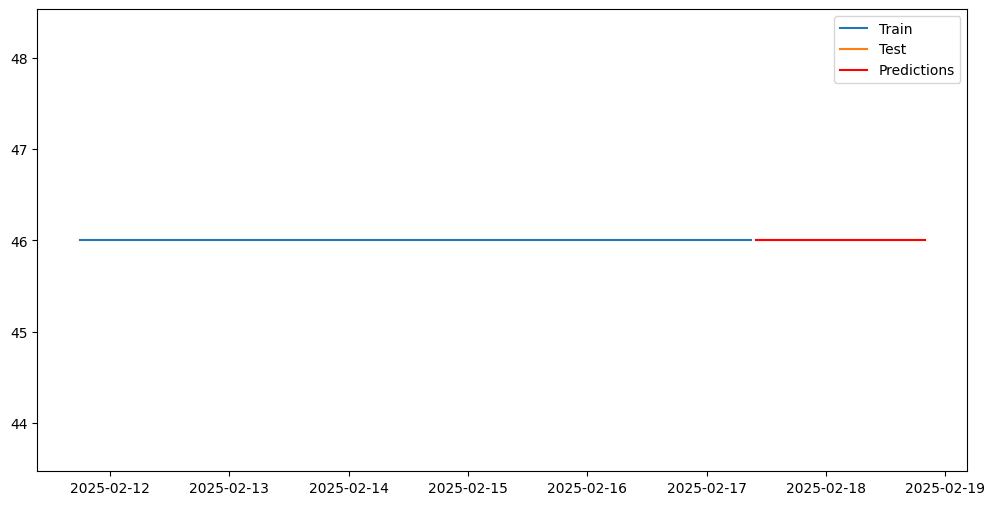

Series([], Name: DeltaTPid, dtype: float64)


In [78]:
from statsmodels.tsa.arima.model import ARIMA # type: ignore

import matplotlib.pyplot as plt

# Seleccionar la serie temporal de interés
series = df_pivoted.set_index('_time')['DeltaTPid']

# Dividir los datos en entrenamiento y prueba
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# Ajustar el modelo ARIMA
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

# Hacer predicciones
predictions = model_fit.forecast(steps=len(test))

# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, predictions, label='Predictions', color='red')
plt.legend()
plt.show()

# Detectar anomalías
anomalies_arima = test[(test - predictions).abs() > 2 * test.std()]
print(anomalies_arima)

### IsolationForest

In [79]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)  # Suponiendo que el 5% de los datos son anomalías
df["Anomaly"] = model.fit_predict(df[["Value"]])


KeyError: "None of [Index(['Value'], dtype='object')] are in the [columns]"

Detectada una anomalia, se modifica setpoint en el PLC en función de la desviación. 

In [ ]:
# si temperatura del intercambiador es muy baja, aumentar setpoint
def adjust_setpoint(sensor, value):
    if sensor == "TT1501" and value < 180:  # Ejemplo de regla
        return value + 10  # Incrementamos el setpoint
    return value

df["New Setpoint"] = df.apply(lambda x: adjust_setpoint(x["Sensor"], x["Value"]), axis=1)


In [ ]:
# envia nuevo setpoint al PLC usando pylogix
from pylogix import PLC

plc = PLC()
plc.IPAddress = "aaa.bbb.ccc.ddd"
plc.Write("TT1501Pid.PID_SpRtn", df["New Setpoint"].iloc[-1])  # Último setpoint ajustado
plc.Close()


## Despliegue

- Conecta los datos en vivo con InfluxDB
- Procesa los datos en Python con Pandas y ML
- Ajusta los setpoints en el PLC cuando hay anamolicas
- automatizar sistema con scripts en 2do plano(Daemon en Linux o servicio en Windows) 

**Visualizar anomalias en Grafana

**Ajustar setpoints con PID+IA